In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from scipy import stats
from scipy.stats import zscore

In [9]:
df = pd.read_csv("../data/benin-malanville.csv", parse_dates=['Timestamp'])
df.head()

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-08-09 00:01:00,-1.2,-0.2,-1.1,0.0,0.0,26.2,93.4,0.0,0.4,0.1,122.1,0.0,998,0,0.0,26.3,26.2,NaN
1,2021-08-09 00:02:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.6,0.0,0.0,0.0,0.0,0.0,998,0,0.0,26.3,26.2,NaN
2,2021-08-09 00:03:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.7,0.3,1.1,0.5,124.6,1.5,997,0,0.0,26.4,26.2,NaN
3,2021-08-09 00:04:00,-1.1,-0.1,-1.0,0.0,0.0,26.2,93.3,0.2,0.7,0.4,120.3,1.3,997,0,0.0,26.4,26.3,NaN
4,2021-08-09 00:05:00,-1.0,-0.1,-1.0,0.0,0.0,26.2,93.3,0.1,0.7,0.3,113.2,1.0,997,0,0.0,26.4,26.3,NaN


In [10]:
df.describe()

# Check missing values
missing_percent = df.isna().mean() * 100
missing_report = missing_percent[missing_percent > 5]
print("Columns with >5% missing values:\n", missing_report)

Columns with >5% missing values:
 Comments    100.0
dtype: float64


In [13]:
# Columns to check for outliers
cols_to_check = ['GHI','DNI','DHI','ModA','ModB','WS','WSgust']

# Z-scores
df_z = df[cols_to_check].apply(zscore)

# Flag outlier rows
outliers = (np.abs(df_z) > 3)
outlier_rows = df[outliers.any(axis=1)]
print(f"Number of outlier rows: {len(outlier_rows)}")

# Impute missing values with median
for col in cols_to_check:
    df[col] = df[col].fillna(df[col].median())

print(f"Total rows in dataset: {len(df)}")
percent_outliers = (len(outlier_rows) / len(df)) * 100
print(f"Percentage of outlier rows: {percent_outliers:.2f}%")



Number of outlier rows: 7740
Total rows in dataset: 525600
Percentage of outlier rows: 1.47%


In [14]:
# median imputation for missing values
for col in ['GHI','DNI','DHI','ModA','ModB','WS','WSgust']:
    df[col] = df[col].fillna(df[col].median())

# cap extreme values to smooth the most extreme spikes
for col in ['GHI','DNI','DHI','ModA','ModB','WS','WSgust']:
    lower, upper = df[col].quantile([0.01, 0.99])
    df[col] = df[col].clip(lower, upper)

# Save cleaned version 
df.to_csv('../data/benin_clean.csv', index=False)
print("Cleaned data saved to ../data/benin_clean.csv")

Cleaned data saved to ../data/benin_clean.csv


In [15]:
# Summary stats
df.describe()

# Missing value report
df.isna().sum()

# Identify columns with >5% nulls
(df.isna().sum() / len(df)) * 100

Timestamp          0.0
GHI                0.0
DNI                0.0
DHI                0.0
ModA               0.0
ModB               0.0
Tamb               0.0
RH                 0.0
WS                 0.0
WSgust             0.0
WSstdev            0.0
WD                 0.0
WDstdev            0.0
BP                 0.0
Cleaning           0.0
Precipitation      0.0
TModA              0.0
TModB              0.0
Comments         100.0
dtype: float64

The dataset for Benin has no missing values in any of the core numeric or sensor columns (GHI, DNI, DHI, ModA, ModB, WS, etc.), which indicates a clean and complete dataset.
However, the Comments column contains 100% missing values, meaning it has no useful data and can be safely dropped before analysis.
Overall, the data quality is excellent with no need for imputation.

In [20]:
print(df.columns.tolist())


['Timestamp', 'GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb', 'RH', 'WS', 'WSgust', 'WSstdev', 'WD', 'WDstdev', 'BP', 'Cleaning', 'Precipitation', 'TModA', 'TModB']


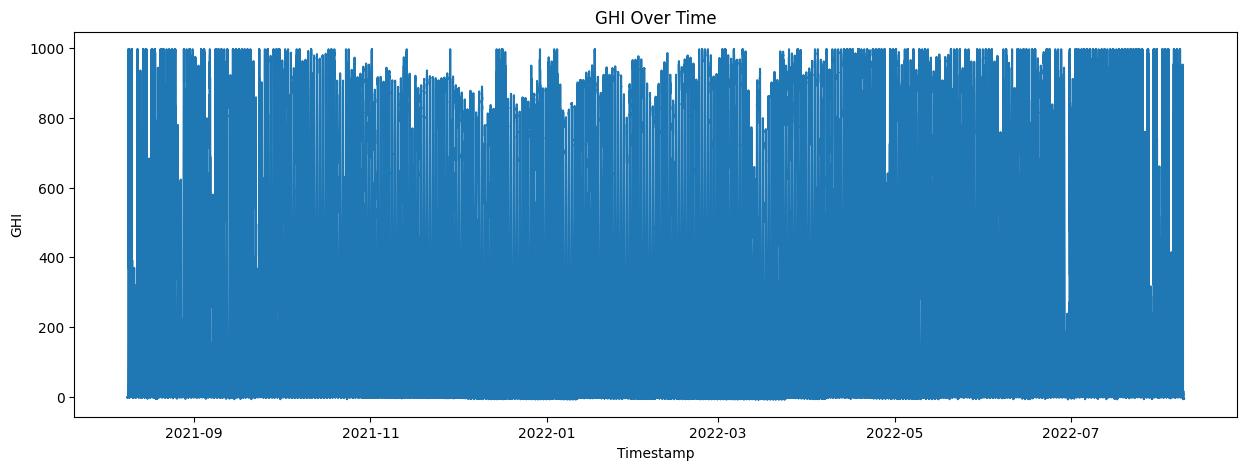

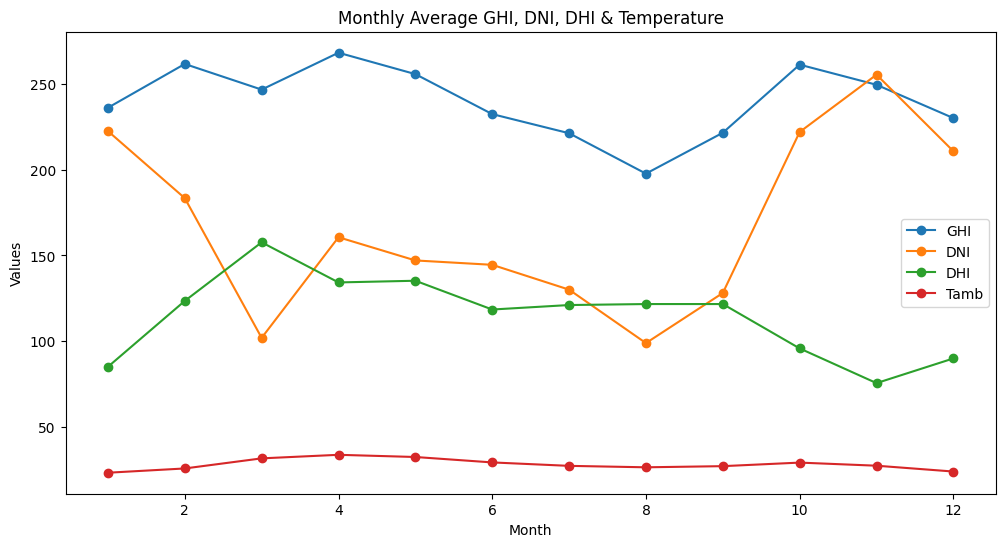

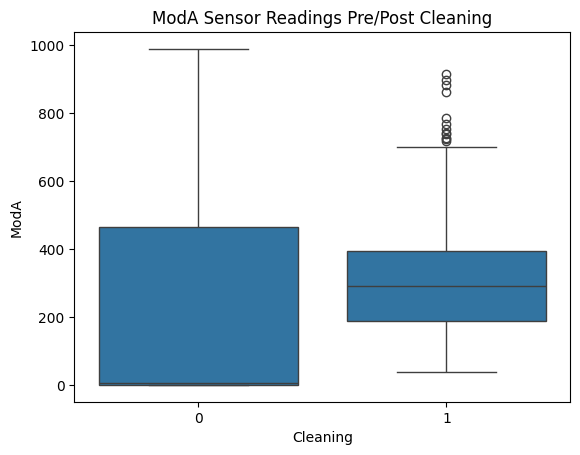

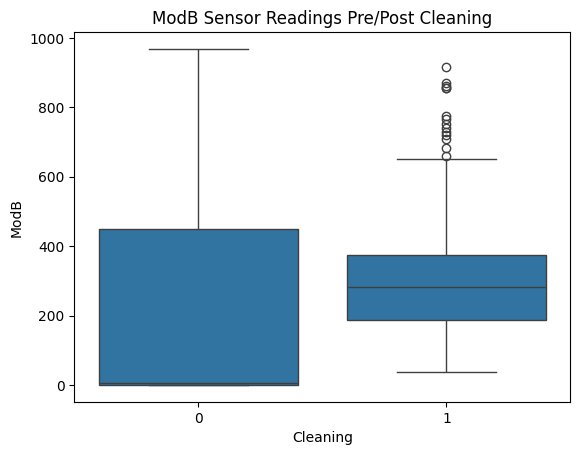

In [21]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# --- 1. Line plot of GHI over time ---
plt.figure(figsize=(15,5))
sns.lineplot(x='Timestamp', y='GHI', data=df)
plt.title('GHI Over Time')
plt.xlabel('Timestamp')
plt.ylabel('GHI')
plt.show()

# --- 2. Monthly averages for solar and temperature ---
df['Month'] = df['Timestamp'].dt.month
monthly_avg = df.groupby('Month')[['GHI','DNI','DHI','Tamb']].mean()

monthly_avg.plot(kind='line', marker='o', figsize=(12,6))
plt.title('Monthly Average GHI, DNI, DHI & Temperature')
plt.ylabel('Values')
plt.show()

# --- 3. Compare ModA & ModB Pre/Post Cleaning ---
sns.boxplot(x='Cleaning', y='ModA', data=df)
plt.title('ModA Sensor Readings Pre/Post Cleaning')
plt.show()

sns.boxplot(x='Cleaning', y='ModB', data=df)
plt.title('ModB Sensor Readings Pre/Post Cleaning')
plt.show()


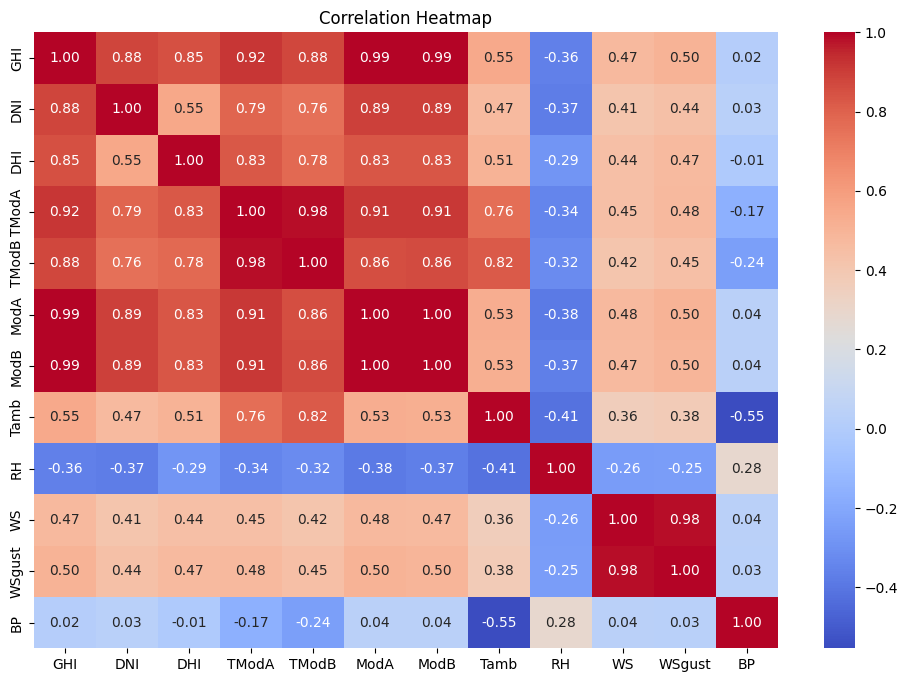

In [22]:

# Select numeric columns for correlation
corr_cols = ['GHI','DNI','DHI','TModA','TModB','ModA','ModB','Tamb','RH','WS','WSgust','BP']
corr_matrix = df[corr_cols].corr()

# Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


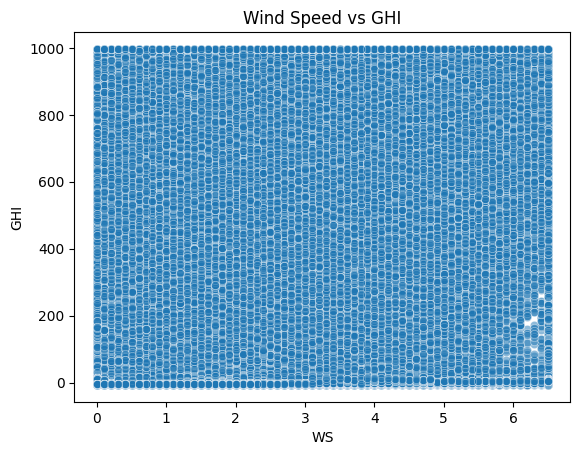

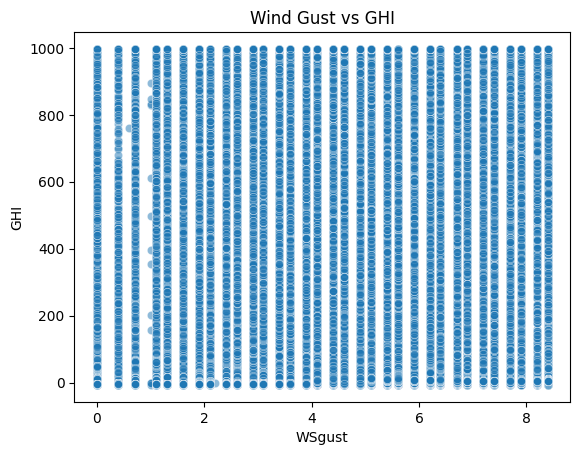

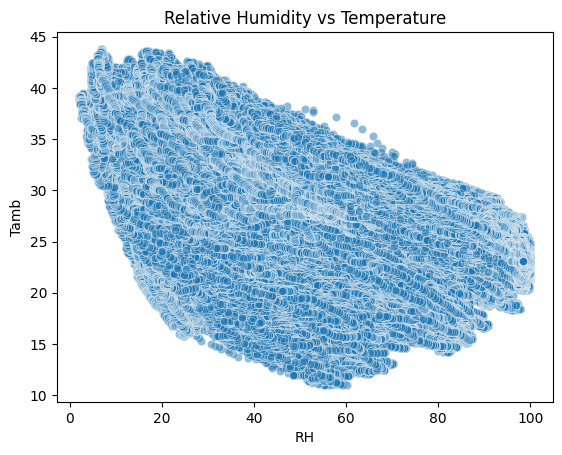

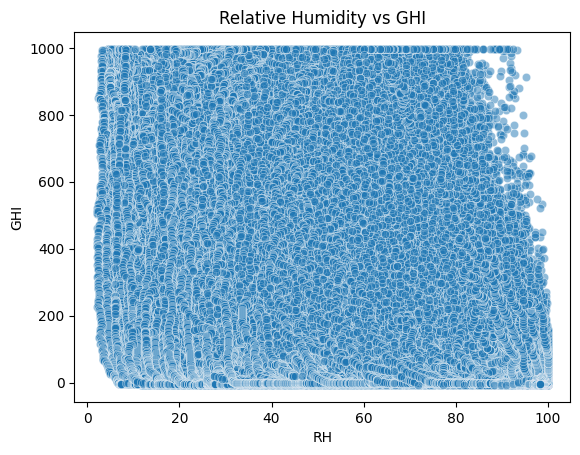

In [23]:
# WS & WSgust vs GHI
sns.scatterplot(data=df, x='WS', y='GHI', alpha=0.5)
plt.title('Wind Speed vs GHI')
plt.show()

sns.scatterplot(data=df, x='WSgust', y='GHI', alpha=0.5)
plt.title('Wind Gust vs GHI')
plt.show()

# RH vs Temperature
sns.scatterplot(data=df, x='RH', y='Tamb', alpha=0.5)
plt.title('Relative Humidity vs Temperature')
plt.show()

# RH vs GHI
sns.scatterplot(data=df, x='RH', y='GHI', alpha=0.5)
plt.title('Relative Humidity vs GHI')
plt.show()


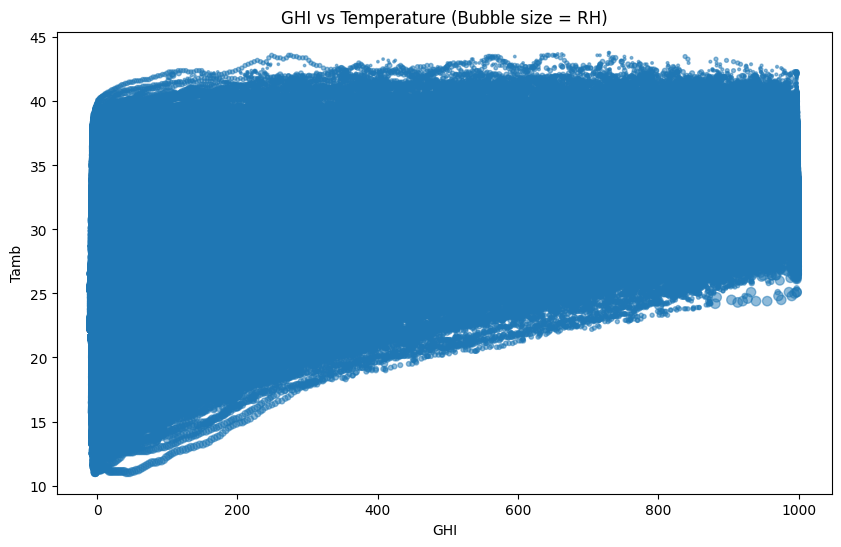

In [24]:
plt.figure(figsize=(10,6))
plt.scatter(df['GHI'], df['Tamb'], s=df['RH']/2, alpha=0.5)
plt.xlabel('GHI')
plt.ylabel('Tamb')
plt.title('GHI vs Temperature (Bubble size = RH)')
plt.show()


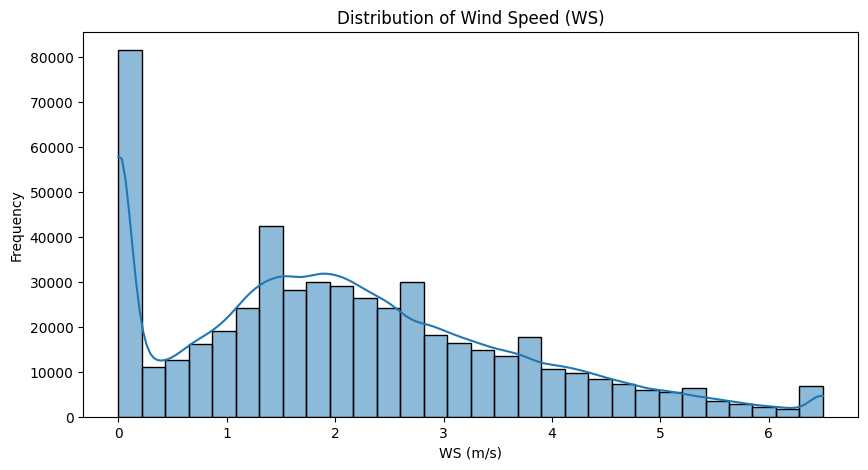

In [25]:
plt.figure(figsize=(10,5))
sns.histplot(df['WS'], bins=30, kde=True)
plt.title('Distribution of Wind Speed (WS)')
plt.xlabel('WS (m/s)')
plt.ylabel('Frequency')
plt.show()

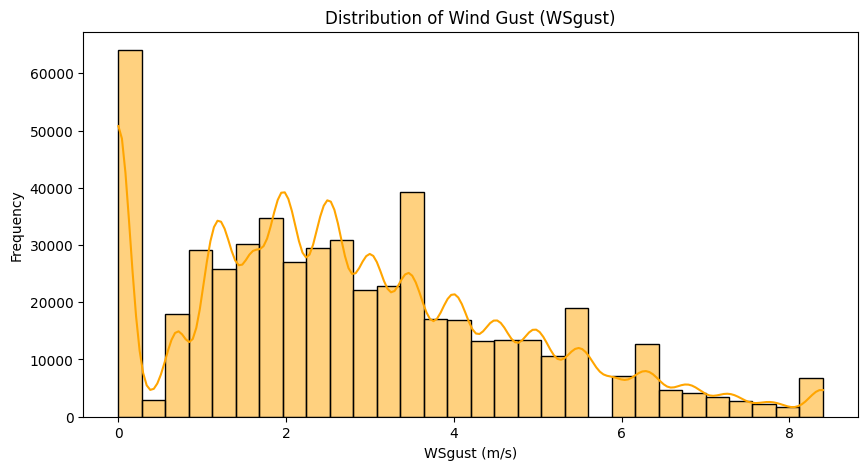

In [26]:
plt.figure(figsize=(10,5))
sns.histplot(df['WSgust'], bins=30, kde=True, color='orange')
plt.title('Distribution of Wind Gust (WSgust)')
plt.xlabel('WSgust (m/s)')
plt.ylabel('Frequency')
plt.show()

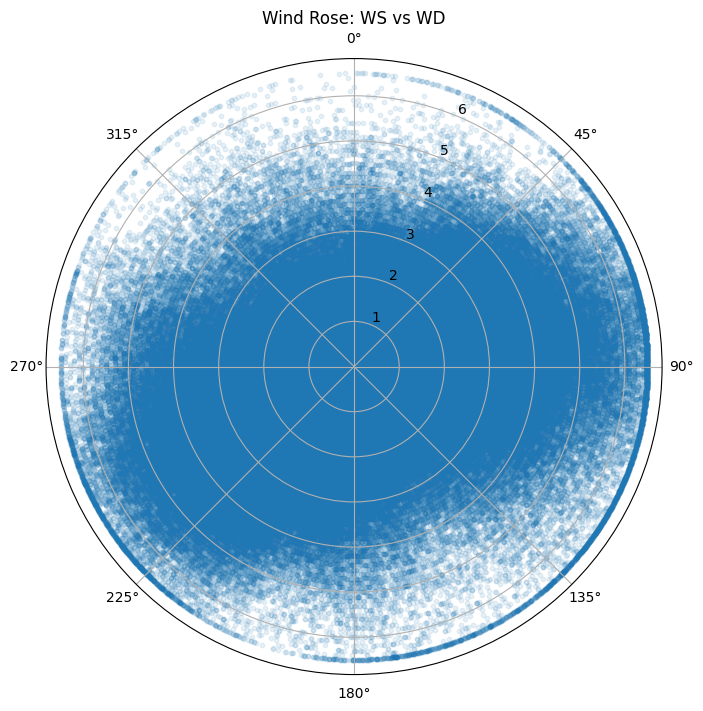

In [27]:
# wind direction to radians
theta = np.deg2rad(df['WD'])
r = df['WS']

plt.figure(figsize=(8,8))
ax = plt.subplot(111, polar=True)
ax.scatter(theta, r, alpha=0.1, s=10)
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
plt.title('Wind Rose: WS vs WD')
plt.show()


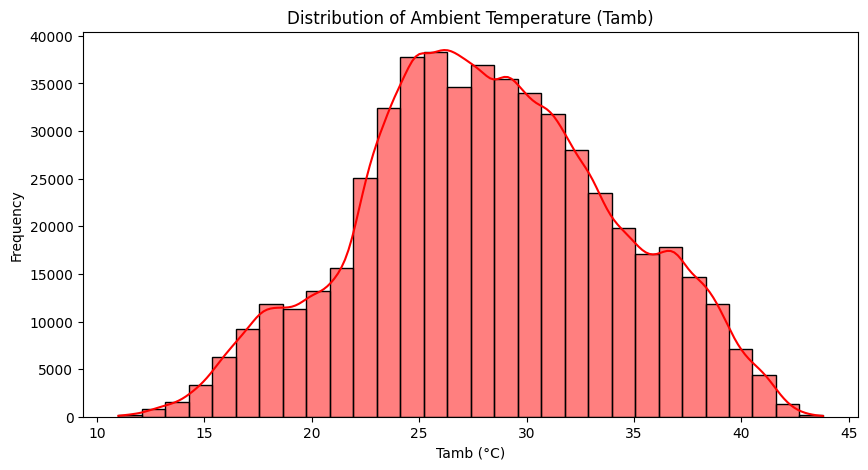

In [28]:
plt.figure(figsize=(10,5))
sns.histplot(df['Tamb'], bins=30, kde=True, color='red')
plt.title('Distribution of Ambient Temperature (Tamb)')
plt.xlabel('Tamb (°C)')
plt.ylabel('Frequency')
plt.show()



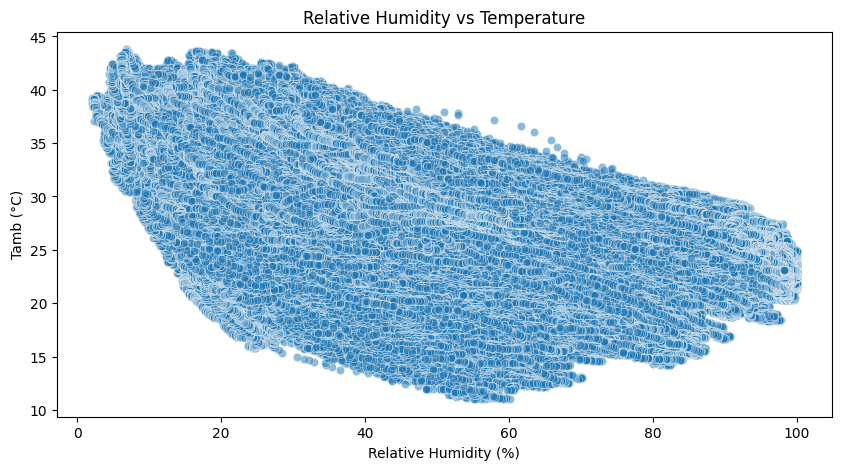

In [29]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='RH', y='Tamb', alpha=0.5)
plt.title('Relative Humidity vs Temperature')
plt.xlabel('Relative Humidity (%)')
plt.ylabel('Tamb (°C)')
plt.show()


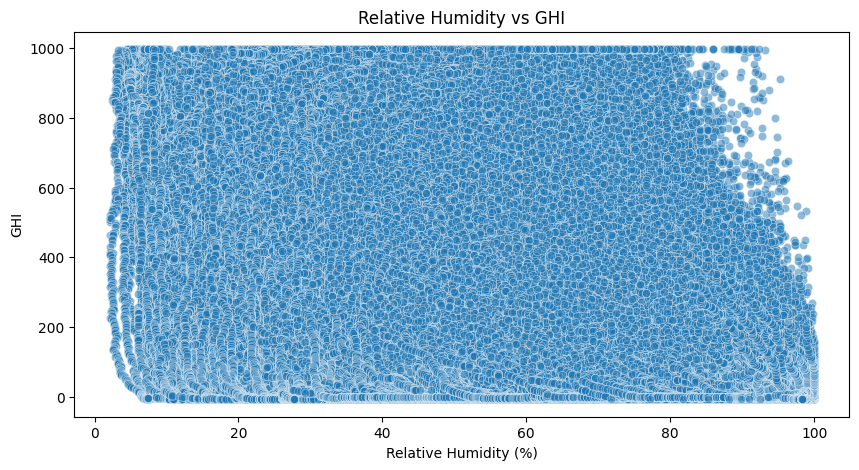

In [30]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='RH', y='GHI', alpha=0.5)
plt.title('Relative Humidity vs GHI')
plt.xlabel('Relative Humidity (%)')
plt.ylabel('GHI')
plt.show()


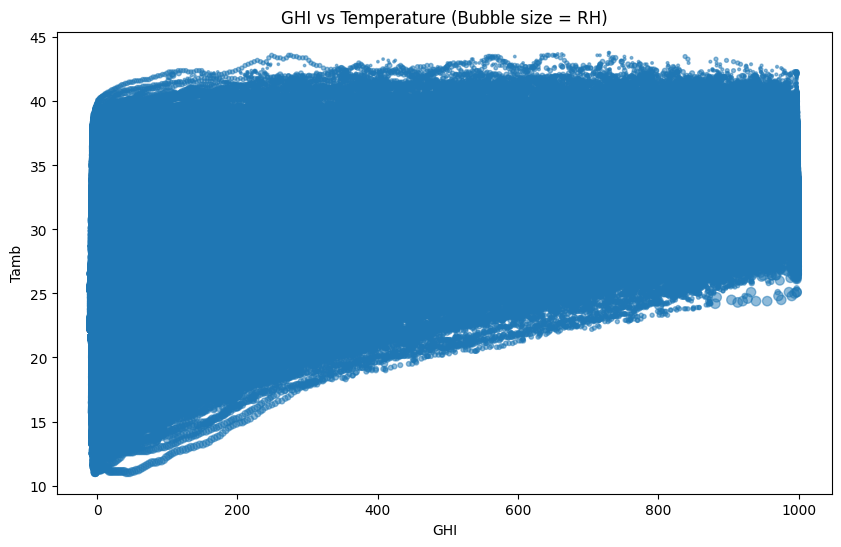

In [31]:
plt.figure(figsize=(10,6))
plt.scatter(df['GHI'], df['Tamb'], s=df['RH']/2, alpha=0.5)
plt.xlabel('GHI')
plt.ylabel('Tamb')
plt.title('GHI vs Temperature (Bubble size = RH)')
plt.show()
